# Injecting Words — Token Embedding Concept Vectors (V1)

Replaces the 4-QA-prompt **residual** concept vector (V4) with a **mean of Llama token embeddings** for the entity name —
motivated by the PopQA V2 finding that token-embed `matches_reference` (32 %) beat Perfect RAG (30 %).

**What changes vs V4:**
- Concept vector = `mean(embed_table[entity_tokens])`, L2-normalised (no forward pass needed)

**What stays the same:**
- `InjectionAdapterV4` — 2-layer MLP 4096→4096
- Phase 1 training: weighted CE + BERTTune (λ=3)
- Injection at Layer 16 via forward hook
- Same `Entities_QA.csv` train/eval split + `Entities_QA_Test_V4.csv` test set

**Final section** loads existing V4 (residual) and RAG baseline CSVs and prints a side-by-side comparison.

## Imports and Setup

Load all required libraries and authenticate with HuggingFace and Gemini.

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import time, json, random, copy, re
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
!pip install matplotlib google-generativeai -q
import matplotlib.pyplot as plt
import google.generativeai as genai

from tqdm.auto import tqdm
from dataclasses import dataclass
from typing import Dict, List, Optional
from typing_extensions import TypedDict
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForCausalLM

HF_TOKEN       = os.getenv("HF_TOKEN")
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    print("HF_TOKEN       : set")
if GEMINI_API_KEY:
    print("GEMINI_API_KEY : set")

if not torch.cuda.is_available():
    raise RuntimeError("No CUDA GPU detected.")
print(f"GPU    : {torch.cuda.get_device_name(0)}")
print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"PyTorch: {torch.__version__}")

/opt/conda/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.13) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/opt/conda/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_12223/1419636024.py:12: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative

HF_TOKEN       : set
GEMINI_API_KEY : set
GPU    : NVIDIA H100 80GB HBM3
VRAM   : 84.9 GB
PyTorch: 2.10.0+cu128


## Configuration

Defines the `Config` dataclass with all hyperparameters for both training phases, plus file path constants.

In [2]:
@dataclass
class Config:
    model_name:           str   = "meta-llama/Llama-3.1-8B-Instruct"
    injection_layer:      int   = 16
    hidden_size:          int   = 4096
    adapter_hidden_dim:   int   = 4096
    adapter_dropout:      float = 0.15
    # Phase-1 training
    phase1_epochs:        int   = 20
    phase1_lr:            float = 5e-4
    batch_size:           int   = 16
    entity_token_weight:  float = 8.0
    berttune_lambda:      float = 3.0
    berttune_top_k:       int   = 128
    early_stop_patience:  int   = 3
    max_seq_len:          int   = 256
    max_new_tokens:       int   = 128
    # Phase-2 GRPO
    grpo_epochs:          int   = 5
    grpo_lr:              float = 1e-5
    grpo_batch_size:      int   = 4
    grpo_num_generations: int   = 4
    grpo_temperature:     float = 0.7
    grpo_kl_coeff:        float = 0.05
    grpo_max_new_tokens:  int   = 64
    grpo_train_per_entity:int   = 2
    judge_model_name:     str   = "Qwen/Qwen2.5-3B-Instruct"

cfg = Config()

BASE_DIR    = "results_v4"
TRAIN_CSV   = os.path.join(BASE_DIR, "Entities_QA.csv")
TRAIN2_CSV  = os.path.join(BASE_DIR, "Entities_QA_Train2_V4.csv")
TEST_CSV    = os.path.join(BASE_DIR, "Entities_QA_Test_V4.csv")
RESULTS_DIR = os.path.join(BASE_DIR, "token_embed")
CACHE_DIR   = os.path.join(BASE_DIR, "learning_cache")
ADAPTER_DIR = os.path.join(BASE_DIR, "trained_adapters")

for d in [RESULTS_DIR, CACHE_DIR, ADAPTER_DIR]:
    os.makedirs(d, exist_ok=True)

print(f"Results → {RESULTS_DIR}")

Results → results_v4/token_embed


## Load Frozen LLM

Loads Llama-3.1-8B-Instruct in bfloat16 and freezes all parameters. The model weights are never updated — only the adapter is trained.

In [3]:
print(f"Loading {cfg.model_name} ...")
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name, token=HF_TOKEN)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"

model = AutoModelForCausalLM.from_pretrained(
    cfg.model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    token=HF_TOKEN,
)
model.eval()
for p in model.parameters():
    p.requires_grad_(False)
print("Model loaded and frozen.")

Loading meta-llama/Llama-3.1-8B-Instruct ...


`torch_dtype` is deprecated! Use `dtype` instead!
/opt/conda/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /opt/conda/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
Loading weights: 100%|██████████| 291/291 [00:01<00:00, 171.07it/s]


Model loaded and frozen.


## Token-Embedding Concept Vector Extractor

**Key difference from V4:** Instead of running 4 QA prompts through the model to extract residual states at Layer 16, we simply look up the embedding table rows for the entity name tokens and take their L2-normalised mean. No forward pass is needed.

In [4]:
# ── Token-embedding concept vector extraction ─────────────────────────────────
# No forward pass needed — just look up the embedding table rows for the entity
# name tokens and take their mean, then L2-normalise.

def get_token_embed_vec(entity: str) -> torch.Tensor:
    tok_ids = tokenizer.encode(entity, add_special_tokens=False)
    if not tok_ids:
        tok_ids = tokenizer.encode(" " + entity, add_special_tokens=False)
    embed_table = model.model.embed_tokens.weight.detach().float()  # [V, H]
    vecs = embed_table[tok_ids]                                      # [T, H]
    return F.normalize(vecs.mean(dim=0), dim=-1).cpu()


def extract_or_load_vecs(csv_path: str, tag: str) -> Dict[str, torch.Tensor]:
    safe = cfg.model_name.replace("/", "_")
    cache = os.path.join(CACHE_DIR, f"{tag}_token_embed_{safe}.pt")
    if os.path.exists(cache):
        vecs = torch.load(cache, map_location="cpu")
        print(f"  Loaded {len(vecs)} vecs from cache: {os.path.basename(cache)}")
        return vecs
    df = pd.read_csv(csv_path)
    vecs = {}
    for ent in tqdm(df["Entity"].dropna().unique(), desc=f"  token-embed ({tag})"):
        vecs[str(ent).lower().strip()] = get_token_embed_vec(str(ent))
    torch.save(vecs, cache)
    print(f"  Saved {len(vecs)} vecs → {os.path.basename(cache)}")
    return vecs

print("Token-embedding extractor ready.")

Token-embedding extractor ready.


## Extract Concept Vectors

Extract and cache token-embedding concept vectors for the train and test splits. Results are saved to disk so this only runs once.

In [5]:
print("Extracting concept vectors...")
all_train_vecs = extract_or_load_vecs(TRAIN_CSV, "trainv4")
test_vecs      = extract_or_load_vecs(TEST_CSV,  "testv4")
print(f"\nTrain entities : {len(all_train_vecs)}")
print(f"Test  entities : {len(test_vecs)}")

Extracting concept vectors...
  Loaded 248 vecs from cache: trainv4_token_embed_meta-llama_Llama-3.1-8B-Instruct.pt
  Loaded 154 vecs from cache: testv4_token_embed_meta-llama_Llama-3.1-8B-Instruct.pt

Train entities : 248
Test  entities : 154


## Adapter and Injection Mechanism

`InjectionAdapterV4` — a 2-layer MLP (Linear → GELU → Dropout → Linear, 4096→4096) that maps a concept vector to a delta added to the residual stream.

`InjectionContext` — a Python context manager that registers a forward hook on Layer 16. During generation it only injects on the first (prefill) forward call; subsequent KV-cache decoding steps are skipped to avoid double-counting.

In [6]:
class InjectionAdapterV4(nn.Module):
    def __init__(self, dim=4096, hidden_dim=4096, dropout=0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, dim),
        )
    def forward(self, x):
        return self.net(x)


class InjectionContext:
    """Context manager: registers a forward hook on layer `layer`.

    Training  — pass inject_positions (list[int], one per batch item).
    Inference — leave inject_positions=None to inject at position -1 (last
                prompt token) only on the first forward call (prefill).
                Subsequent calls are the KV-cache decoding steps; the
                injected state is already baked into the cached K/V pairs,
                so re-injecting would double-count.
    """
    def __init__(self, model, adapter, concept_vecs, inject_positions=None, layer=16):
        self.model            = model
        self.adapter          = adapter
        self.concept_vecs     = concept_vecs   # [B, H]
        self.inject_positions = inject_positions
        self.layer            = layer
        self._handle          = None
        self._calls           = 0

    def _hook_fn(self, module, input, output):
        # During generation: skip all calls after the first (prefill).
        if self.inject_positions is None and self._calls > 0:
            self._calls += 1
            return output

        # Newer transformers versions return the hidden states tensor directly;
        # older versions return a tuple (hidden_states, ...).
        is_tuple = isinstance(output, tuple)
        hs = output[0].clone() if is_tuple else output.clone()   # [B, S, H]

        deltas = self.adapter(
            self.concept_vecs.to(device=hs.device, dtype=hs.dtype)
        )                        # [B, H]
        for b in range(hs.shape[0]):
            idx = self.inject_positions[b] if self.inject_positions is not None else -1
            hs[b, idx, :] = hs[b, idx, :] + deltas[b]
        self._calls += 1

        return (hs,) + output[1:] if is_tuple else hs

    def __enter__(self):
        self._calls = 0
        self._handle = self.model.model.layers[self.layer].register_forward_hook(self._hook_fn)
        return self

    def __exit__(self, *_):
        if self._handle:
            self._handle.remove()
            self._handle = None

print("InjectionAdapterV4 + InjectionContext defined.")

InjectionAdapterV4 + InjectionContext defined.


## Dataset and DataLoader Utilities

`EntityQADataset` wraps the CSV rows and pairs each one with its concept vector. `make_collate` builds the batches: it tokenises prompt+answer together, computes per-token weight masks (entity tokens upweighted 8×), and records the injection position (last prompt token index).

In [7]:
def find_entity_positions(answer_ids: List[int], entity: str) -> List[int]:
    """Return indices in answer_ids that belong to entity tokens (first match)."""
    ent_ids = tokenizer.encode(entity, add_special_tokens=False)
    for i in range(len(answer_ids) - len(ent_ids) + 1):
        if answer_ids[i : i + len(ent_ids)] == ent_ids:
            return list(range(i, i + len(ent_ids)))
    # Try with leading space
    ent_ids2 = tokenizer.encode(" " + entity, add_special_tokens=False)
    for i in range(len(answer_ids) - len(ent_ids2) + 1):
        if answer_ids[i : i + len(ent_ids2)] == ent_ids2:
            return list(range(i, i + len(ent_ids2)))
    return []


class EntityQADataset(Dataset):
    def __init__(self, df: pd.DataFrame, concept_vecs: Dict[str, torch.Tensor]):
        self.items = []
        for _, row in df.iterrows():
            key = str(row["Entity"]).lower().strip()
            if key not in concept_vecs:
                continue
            self.items.append({
                "key":      key,
                "entity":   str(row["Entity"]),
                "category": str(row.get("Category", "")),
                "question": str(row["Question"]),
                "answer":   str(row["Answer"]),
            })

    def __len__(self):  return len(self.items)
    def __getitem__(self, i): return self.items[i]


def make_collate(concept_vecs: Dict[str, torch.Tensor]):
    def collate_fn(batch):
        prompt_texts = [f"Question: {r['question']}\nAnswer:" for r in batch]
        answer_texts = [f" {r['answer']}" for r in batch]
        full_texts   = [p + a for p, a in zip(prompt_texts, answer_texts)]

        enc = tokenizer(
            full_texts, return_tensors="pt", padding=True,
            truncation=True, max_length=cfg.max_seq_len,
        )
        seq_len = enc["input_ids"].shape[1]

        prompt_ids_list = [
            tokenizer.encode(p, add_special_tokens=False) for p in prompt_texts
        ]
        answer_ids_list = [
            tokenizer.encode(a, add_special_tokens=False) for a in answer_texts
        ]

        inject_positions = []
        weight_masks     = []
        for b, r in enumerate(batch):
            pad_len   = int((enc["attention_mask"][b] == 0).sum().item())
            p_len     = len(prompt_ids_list[b])
            a_ids     = answer_ids_list[b]
            inject_positions.append(pad_len + p_len - 1)

            # Weight tensor over shifted sequence (length = seq_len - 1)
            w = torch.zeros(seq_len - 1)
            ans_start = pad_len + p_len - 1   # first answer token in shifted seq
            ans_end   = min(ans_start + len(a_ids), seq_len - 1)
            w[ans_start:ans_end] = 1.0
            # Upweight entity tokens
            ent_pos = find_entity_positions(a_ids, r["entity"])
            for ep in ent_pos:
                shifted_ep = ans_start + ep
                if shifted_ep < seq_len - 1:
                    w[shifted_ep] = cfg.entity_token_weight
            weight_masks.append(w)

        concept_vecs_batch = torch.stack(
            [concept_vecs[r["key"]] for r in batch]
        )

        return {
            "input_ids":         enc["input_ids"],
            "attention_mask":    enc["attention_mask"],
            "concept_vecs":      concept_vecs_batch,
            "inject_positions":  inject_positions,
            "weight_masks":      torch.stack(weight_masks),
            "answer_ids_list":   answer_ids_list,
            "keys":              [r["key"]      for r in batch],
            "entities":          [r["entity"]   for r in batch],
            "questions":         [r["question"] for r in batch],
            "answers":           [r["answer"]   for r in batch],
            "categories":        [r["category"] for r in batch],
        }
    return collate_fn

print("Dataset utilities defined.")

Dataset utilities defined.


## Training Loss: Weighted CE + BERTTune

Two components:
1. **Weighted cross-entropy** — answer tokens get weight 1, entity tokens get weight 8 (upweighted to encourage entity mention).
2. **BERTTune semantic loss** — cosine distance between the soft embedding (top-128 logit-weighted vocab embeddings) and the reference embedding. Encourages semantically correct generation beyond exact token match.

In [8]:
def compute_loss(
    logits,          # [B, S, V]
    input_ids,       # [B, S]
    weight_masks,    # [B, S-1]  0=ignore, 1=answer, 8=entity
    embed_matrix,    # [V, H]  pre-computed once before training
    berttune_lambda: float = 3.0,
):
    shift_logits = logits[:, :-1, :].float()   # [B, S-1, V]
    shift_labels = input_ids[:, 1:]            # [B, S-1]
    B, S1, V = shift_logits.shape

    # ── Weighted CE ───────────────────────────────────────────────────────────
    ce = F.cross_entropy(
        shift_logits.reshape(-1, V),
        shift_labels.reshape(-1),
        reduction="none",
    ).reshape(B, S1)
    w = weight_masks.to(ce.device)
    loss_ce = (ce * w).sum() / (w.sum() + 1e-8)

    # ── BERTTune semantic loss (top-k soft-embedding approximation) ───────────
    em = embed_matrix.to(device=shift_logits.device, dtype=shift_logits.dtype)
    loss_sem = torch.tensor(0.0, device=logits.device)
    n_valid  = 0
    for b in range(B):
        ans_mask = w[b] > 0
        if ans_mask.sum() == 0:
            continue
        item_logits = shift_logits[b][ans_mask]
        item_labels = shift_labels[b][ans_mask]
        top_vals, top_ids = torch.topk(item_logits, cfg.berttune_top_k, dim=-1)
        soft_probs  = F.softmax(top_vals, dim=-1).unsqueeze(-1)   # [N, k, 1]
        top_embeds  = em[top_ids]                                  # [N, k, H]
        soft_embeds = (soft_probs * top_embeds).sum(dim=1)         # [N, H]
        ref_embeds  = em[item_labels]                              # [N, H]
        cos         = F.cosine_similarity(
            soft_embeds.mean(dim=0, keepdim=True),
            ref_embeds.mean(dim=0, keepdim=True),
        )
        loss_sem += 1.0 - cos.squeeze()
        n_valid  += 1

    if n_valid == 0:
        print("WARNING: no valid answer tokens in batch — BERTTune skipped")
    else:
        loss_sem = loss_sem / n_valid

    return loss_ce + berttune_lambda * loss_sem, loss_ce.item(), loss_sem.item()

print("Loss function defined.")

Loss function defined.


## Phase 1: Dataset Splits and Adapter Setup

Applies the same 80/20 stratified train/eval split as V4 (stratified by category × entity). Initialises `InjectionAdapterV4` and the AdamW optimiser.

In [9]:
# ── Build train/eval splits (same strategy as V4: 1 val example per entity) ──
df_full = pd.read_csv(TRAIN_CSV)
df_full["_key"] = df_full["Entity"].str.lower().str.strip()

# Filter to entities that have concept vectors
df_full = df_full[df_full["_key"].isin(all_train_vecs)].reset_index(drop=True)

# Group by (category, entity) and pick 1 val example per group — same as V4
random.seed(42)
grouped = {}
for _, row in df_full.iterrows():
    key = (row["Category"].strip(), row["_key"])
    grouped.setdefault(key, []).append(row)

train_rows, eval_rows = [], []
for examples in grouped.values():
    val_row = random.choice(examples)
    eval_rows.append(val_row)
    train_rows.extend([r for r in examples if r is not val_row])

train_df = pd.DataFrame(train_rows).reset_index(drop=True)
eval_df  = pd.DataFrame(eval_rows).reset_index(drop=True)
print(f"Train: {len(train_df)} rows  |  Eval: {len(eval_df)} rows")

train_ds = EntityQADataset(train_df, all_train_vecs)
eval_ds  = EntityQADataset(eval_df,  all_train_vecs)

train_collate = make_collate(all_train_vecs)

train_loader = DataLoader(
    train_ds, batch_size=cfg.batch_size, shuffle=True,
    collate_fn=train_collate, drop_last=False,
)
eval_loader = DataLoader(
    eval_ds, batch_size=cfg.batch_size, shuffle=False,
    collate_fn=train_collate, drop_last=False,
)
print(f"Train batches: {len(train_loader)}  |  Eval batches: {len(eval_loader)}")

# ── Instantiate adapter + optimiser ──────────────────────────────────────────
device  = next(model.parameters()).device
model_dtype = next(model.parameters()).dtype   # bfloat16
adapter = InjectionAdapterV4(
    dim=cfg.hidden_size,
    hidden_dim=cfg.adapter_hidden_dim,
    dropout=cfg.adapter_dropout,
).to(device=device, dtype=model_dtype)
optimiser = torch.optim.AdamW(adapter.parameters(), lr=cfg.phase1_lr)
print(f"Adapter dtype: {model_dtype}  |  parameters: {sum(p.numel() for p in adapter.parameters()):,}")

Train: 1389 rows  |  Eval: 279 rows
Train batches: 87  |  Eval batches: 18
Adapter dtype: torch.bfloat16  |  parameters: 33,562,624


## Phase 1: Supervised Training Loop

Trains the adapter with weighted CE + BERTTune loss for up to 20 epochs with early stopping (patience=3). The best checkpoint (lowest validation loss) is saved and reloaded at the end.

In [10]:
# Pre-compute once — avoids repeated dtype conversion inside every batch
embed_matrix = model.model.embed_tokens.weight.detach().cpu()

def run_epoch(loader, training: bool):
    adapter.train(training)
    total_loss = total_ce = total_sem = 0.0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, leave=False, desc="train" if training else "eval"):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            concept_vecs   = batch["concept_vecs"].to(device)
            weight_masks   = batch["weight_masks"].to(device)
            inject_pos     = batch["inject_positions"]

            with InjectionContext(model, adapter, concept_vecs, inject_pos, cfg.injection_layer):
                outputs = model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                )

            loss, lce, lsem = compute_loss(
                outputs.logits, input_ids, weight_masks,
                embed_matrix, cfg.berttune_lambda,
            )

            if training:
                optimiser.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(adapter.parameters(), 1.0)
                optimiser.step()

            total_loss += loss.item()
            total_ce   += lce
            total_sem  += lsem

    n = len(loader)
    return total_loss / n, total_ce / n, total_sem / n


best_val_loss  = float("inf")
patience_count = 0
safe_model     = cfg.model_name.replace("/", "_")
adapter_path   = os.path.join(ADAPTER_DIR, f"adapter_{safe_model}_token_embed_phase1.pt")

print(f"Starting Phase-1 training ({cfg.phase1_epochs} epochs max) ...\n")
for epoch in range(1, cfg.phase1_epochs + 1):
    tr_loss, tr_ce, tr_sem = run_epoch(train_loader, training=True)
    val_loss, val_ce, val_sem = run_epoch(eval_loader, training=False)

    print(f"Ep {epoch:02d}  "
          f"train loss={tr_loss:.4f} (ce={tr_ce:.4f} sem={tr_sem:.4f})  "
          f"val loss={val_loss:.4f} (ce={val_ce:.4f} sem={val_sem:.4f})")

    if val_loss < best_val_loss:
        best_val_loss  = val_loss
        patience_count = 0
        torch.save(adapter.state_dict(), adapter_path)
        print(f"  Saved best adapter (val_loss={best_val_loss:.4f})")
    else:
        patience_count += 1
        if patience_count >= cfg.early_stop_patience:
            print(f"  Early stop at epoch {epoch}.")
            break

print("\nLoading best checkpoint ...")
adapter.load_state_dict(torch.load(adapter_path, map_location=device))
adapter.eval()
print("Done.")

Starting Phase-1 training (20 epochs max) ...



Ep 01  train loss=2.2576 (ce=1.8591 sem=0.1328)  val loss=1.7345 (ce=1.3864 sem=0.1160)
  Saved best adapter (val_loss=1.7345)


Ep 02  train loss=1.4788 (ce=1.1752 sem=0.1012)  val loss=1.3815 (ce=1.0901 sem=0.0971)
  Saved best adapter (val_loss=1.3815)


Ep 03  train loss=1.1902 (ce=0.9336 sem=0.0855)  val loss=1.3151 (ce=1.0297 sem=0.0951)
  Saved best adapter (val_loss=1.3151)


Ep 04  train loss=1.0495 (ce=0.8163 sem=0.0777)  val loss=1.2572 (ce=0.9881 sem=0.0897)
  Saved best adapter (val_loss=1.2572)


Ep 05  train loss=0.9614 (ce=0.7465 sem=0.0716)  val loss=1.2915 (ce=1.0169 sem=0.0915)


Ep 06  train loss=0.8766 (ce=0.6807 sem=0.0653)  val loss=1.3467 (ce=1.0589 sem=0.0959)


Ep 07  train loss=0.7903 (ce=0.6146 sem=0.0586)  val loss=1.3871 (ce=1.0921 sem=0.0983)
  Early stop at epoch 7.

Loading best checkpoint ...
Done.


## Phase 2 GRPO: Prepare Training Data

Builds the GRPO training set from two sources:
1. **Train-1 subset** — `grpo_train_per_entity` (=2) QA pairs per entity from the Phase-1 train split (seen entities, reinforces already-learned associations).
2. **Train-2** — all rows from `Entities_QA_Train2_V4.csv` (unseen entities, forces generalisation to new entities).

In [11]:
def df_to_items(df: pd.DataFrame, vecs: Dict[str, torch.Tensor]) -> list:
    items = []
    for _, row in df.iterrows():
        key = str(row["Entity"]).lower().strip()
        if key not in vecs:
            continue
        items.append({
            "key":         key,
            "entity":      str(row["Entity"]),
            "question":    str(row["Question"]),
            "answer":      str(row["Answer"]),
            "concept_vec": vecs[key],
        })
    return items


def build_grpo_data(train_df_: pd.DataFrame, vecs_: Dict[str, torch.Tensor]) -> tuple:
    """Build GRPO items from the Train-1 subset + Train-2 unseen entities."""
    # Train-1 subset: grpo_train_per_entity QA pairs per entity from Phase-1 train data
    rows = []
    for ent in train_df_["Entity"].str.lower().str.strip().unique():
        ent_rows = train_df_[train_df_["Entity"].str.lower().str.strip() == ent]
        rows.append(ent_rows.sample(min(cfg.grpo_train_per_entity, len(ent_rows)), random_state=42))
    df_t1  = pd.concat(rows, ignore_index=True)
    items1 = df_to_items(df_t1, vecs_)

    # Train-2: unseen entities from Entities_QA_Train2_V4.csv
    t2_vecs = extract_or_load_vecs(TRAIN2_CSV, "train2v4")
    df_t2   = pd.read_csv(TRAIN2_CSV)
    items2  = df_to_items(df_t2, t2_vecs)

    all_items = items1 + items2
    random.shuffle(all_items)
    print(f"GRPO data: {len(items1)} train-1 + {len(items2)} train-2 = {len(all_items)} total")
    return all_items, t2_vecs


grpo_items, train2_vecs = build_grpo_data(train_df, all_train_vecs)
print(f"GRPO training items ready: {len(grpo_items)}")

  Loaded 154 vecs from cache: train2v4_token_embed_meta-llama_Llama-3.1-8B-Instruct.pt
GRPO data: 494 train-1 + 154 train-2 = 648 total
GRPO training items ready: 648


## Phase 2 GRPO: Load Qwen Reward Model

Loads `Qwen/Qwen2.5-3B-Instruct` as a local reward model. All weights are frozen — it is only used for inference to score completions during the GRPO loop.

In [12]:
print(f"Loading {cfg.judge_model_name} ...")
qwen_tokenizer = AutoTokenizer.from_pretrained(cfg.judge_model_name)
qwen_model     = AutoModelForCausalLM.from_pretrained(
    cfg.judge_model_name,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
qwen_model.eval()
for p in qwen_model.parameters():
    p.requires_grad_(False)
print("Qwen loaded.")

Loading Qwen/Qwen2.5-3B-Instruct ...


Loading weights: 100%|██████████| 434/434 [00:00<00:00, 570.22it/s]


Qwen loaded.


## Phase 2 GRPO: Utilities

Three functions used inside the GRPO loop:
- `qwen_judge_reward` — queries the local Qwen model for a binary contains_entity / matches_reference score and returns a scalar reward ∈ {0, 0.5, 1}.
- `generate_with_injection` — samples one stochastic completion from Llama with the adapter injected.
- `compute_log_probs` — computes the sum of log-probs over the generated tokens (used for the policy gradient and KL penalty).

In [13]:
def qwen_judge_reward(item: dict, generated: str) -> float:
    prompt = (
        "You are an expert evaluator for a question-answering system.\n"
        "Analyze the following and return a JSON object.\n\n"
        "**Input:**\n"
        f"- Entity: \"{item['entity']}\"\n"
        f"- Question: \"{item['question']}\"\n"
        f"- Gold Answer: \"{item['answer']}\"\n"
        f"- Generated Answer: \"{generated}\"\n\n"
        "**Task:** Evaluate on these 2 metrics (0.0=no, 1.0=yes):\n"
        f"1. contains_entity: Does the generated answer mention \"{item['entity']}\"?\n"
        "2. matches_reference: Does the generated answer convey the same core info as the gold answer? They do not need to be word-for-word identical. A short answer (even just the entity name) is correct if it provides the key information. Focus on whether the generated answer would be considered a correct response to the question.\n\n"
        "**Output:** Return ONLY a JSON object: "
        '{"contains_entity": float, "matches_reference": float}'
    )
    messages = [
        {"role": "system", "content": "You are a strict JSON output machine. Output only valid JSON."},
        {"role": "user",   "content": prompt},
    ]
    text   = qwen_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = qwen_tokenizer(text, return_tensors="pt").to(qwen_model.device)
    with torch.no_grad():
        outputs = qwen_model.generate(
            **inputs, max_new_tokens=80, do_sample=False,
            pad_token_id=qwen_tokenizer.eos_token_id,
        )
    response = qwen_tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )
    try:
        raw    = response.strip().lstrip("```json").lstrip("```").rstrip("```").strip()
        result = json.loads(raw)
        ce     = float(result.get("contains_entity",   0.0))
        mr     = float(result.get("matches_reference", 0.0))
        return 0.5 * ce + 0.5 * mr
    except Exception:
        return 0.0


def generate_with_injection(model, tokenizer, adapter, item, cfg,
                            num_return: int = 1, temperature: float = 0.7):
    vec   = item["concept_vec"].unsqueeze(0).to(model.device)
    layer = model.model.layers[cfg.injection_layer]

    prompt = f"Question: {item['question']}\nAnswer:"
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

    with torch.no_grad():
        injection_vec = adapter(
            vec.to(dtype=next(adapter.parameters()).dtype)
        ).squeeze(0)

    inject_idx = inputs["input_ids"].shape[1] - 1

    def _hook(module, args, output):
        hs = output[0] if isinstance(output, tuple) else output
        if inject_idx < hs.shape[1]:
            hs[0, inject_idx, :] = hs[0, inject_idx, :] + injection_vec
        return (hs,) + output[1:] if isinstance(output, tuple) else hs

    generations = []
    for _ in range(num_return):
        handle = layer.register_forward_hook(_hook)
        try:
            with torch.no_grad():
                out_ids = model.generate(
                    **inputs,
                    max_new_tokens=cfg.grpo_max_new_tokens,
                    do_sample=(temperature > 0),
                    temperature=temperature if temperature > 0 else None,
                    pad_token_id=tokenizer.eos_token_id,
                )
        finally:
            handle.remove()
        generations.append(
            tokenizer.decode(out_ids[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        )
    return generations


def compute_log_probs(model, tokenizer, adapter, item, generated_text, cfg):
    vec        = item["concept_vec"].unsqueeze(0).to(model.device)
    layer      = model.model.layers[cfg.injection_layer]

    prompt     = f"Question: {item['question']}\nAnswer:"
    answer_str = generated_text + tokenizer.eos_token

    prompt_ids = tokenizer.encode(prompt, add_special_tokens=False)
    ans_ids    = tokenizer.encode(answer_str, add_special_tokens=False)
    full_ids   = torch.tensor(prompt_ids + ans_ids, dtype=torch.long).unsqueeze(0).to(model.device)

    injection_vec = adapter(vec.to(dtype=next(adapter.parameters()).dtype)).squeeze(0)
    inject_idx    = len(prompt_ids) - 1

    def _hook(module, args, output):
        hs = output[0] if isinstance(output, tuple) else output
        if inject_idx < hs.shape[1]:
            hs[0, inject_idx, :] = hs[0, inject_idx, :] + injection_vec
        return (hs,) + output[1:] if isinstance(output, tuple) else hs

    handle = layer.register_forward_hook(_hook)
    try:
        outputs = model(input_ids=full_ids, use_cache=False)
    finally:
        handle.remove()

    logits       = outputs.logits[:, :-1, :]
    targets      = full_ids[:, 1:]
    log_probs    = F.log_softmax(logits.float(), dim=-1)
    token_lps    = log_probs.gather(2, targets.unsqueeze(-1)).squeeze(-1)
    answer_start = len(prompt_ids) - 1
    return token_lps[0, answer_start:].sum()

print("GRPO utilities defined.")

GRPO utilities defined.


## Phase 2 GRPO: Training Loop

GRPO with G=4 samples per prompt. For each item: sample G completions → score with Qwen → compute advantages → policy gradient loss + KL penalty against the frozen Phase-1 reference adapter. After training, Qwen is deleted to free VRAM.

In [14]:
def train_grpo(cfg, model, tokenizer, adapter, grpo_data):
    optimizer   = torch.optim.AdamW(adapter.parameters(), lr=cfg.grpo_lr)
    history     = {"reward_mean": [], "reward_std": [], "policy_loss": [], "kl_loss": []}
    ref_adapter = copy.deepcopy(adapter)
    ref_adapter.eval()
    for p in ref_adapter.parameters():
        p.requires_grad_(False)

    for epoch in range(cfg.grpo_epochs):
        adapter.train()
        random.shuffle(grpo_data)
        epoch_rewards, epoch_pol, epoch_kl = [], [], []

        pbar = tqdm(range(0, len(grpo_data), cfg.grpo_batch_size),
                    desc=f"GRPO Epoch {epoch+1}/{cfg.grpo_epochs}")
        for i in pbar:
            batch_items = grpo_data[i : i + cfg.grpo_batch_size]
            total_pol   = torch.tensor(0.0, device=device, requires_grad=True)
            total_kl    = torch.tensor(0.0, device=device)
            n_valid     = 0

            for item in batch_items:
                # Generate G completions
                adapter.eval()
                gens = generate_with_injection(
                    model, tokenizer, adapter, item, cfg,
                    num_return=cfg.grpo_num_generations,
                    temperature=cfg.grpo_temperature,
                )

                # Score with Qwen judge
                rewards    = [qwen_judge_reward(item, g) for g in gens]
                rewards_t  = torch.tensor(rewards, dtype=torch.float)
                mean_r     = rewards_t.mean()
                std_r      = rewards_t.std().clamp(min=1e-8)
                advantages = (rewards_t - mean_r) / std_r
                epoch_rewards.extend(rewards)

                # Policy gradient + KL penalty
                adapter.train()
                for gen, adv in zip(gens, advantages.tolist()):
                    if abs(adv) < 1e-6 or not gen.strip():
                        continue
                    lp_cur = compute_log_probs(model, tokenizer, adapter, item, gen, cfg)
                    with torch.no_grad():
                        lp_ref = compute_log_probs(model, tokenizer, ref_adapter, item, gen, cfg)
                    pol_loss  = -adv * lp_cur
                    kl        = (lp_cur - lp_ref).clamp(min=0).detach()
                    total_pol = total_pol + pol_loss
                    total_kl  = total_kl  + kl
                    n_valid  += 1

            if n_valid > 0:
                loss = (total_pol + cfg.grpo_kl_coeff * total_kl) / n_valid
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(adapter.parameters(), 1.0)
                optimizer.step()
                epoch_pol.append(total_pol.item() / n_valid)
                epoch_kl.append(total_kl.item()   / n_valid)
                pbar.set_postfix(reward=f"{mean_r.item():.3f}")

        history["reward_mean"].append(float(np.mean(epoch_rewards)) if epoch_rewards else 0.0)
        history["reward_std"].append(float(np.std(epoch_rewards))   if epoch_rewards else 0.0)
        history["policy_loss"].append(float(np.mean(epoch_pol)) if epoch_pol else 0.0)
        history["kl_loss"].append(float(np.mean(epoch_kl))      if epoch_kl  else 0.0)
        print(f"  GRPO Epoch {epoch+1}: reward={history['reward_mean'][-1]:.3f} "
              f"± {history['reward_std'][-1]:.3f}")
    return history


grpo_history = train_grpo(cfg, model, tokenizer, adapter, grpo_items)

safe_model = cfg.model_name.replace("/", "_")
grpo_path  = os.path.join(ADAPTER_DIR, f"adapter_{safe_model}_token_embed_phase2.pt")
torch.save(adapter.state_dict(), grpo_path)
print(f"Phase-2 adapter saved → {grpo_path}")

# Free Qwen to reclaim VRAM before inference
del qwen_model, qwen_tokenizer
torch.cuda.empty_cache()
print("Qwen freed.")

GRPO Epoch 1/5: 100%|██████████| 162/162 [1:07:04<00:00, 24.84s/it, reward=0.500]


  GRPO Epoch 1: reward=0.500 ± 0.255


GRPO Epoch 2/5: 100%|██████████| 162/162 [1:07:12<00:00, 24.89s/it, reward=0.600]


  GRPO Epoch 2: reward=0.502 ± 0.252


GRPO Epoch 3/5: 100%|██████████| 162/162 [1:07:07<00:00, 24.86s/it, reward=0.500]


  GRPO Epoch 3: reward=0.498 ± 0.254


GRPO Epoch 4/5: 100%|██████████| 162/162 [1:07:23<00:00, 24.96s/it, reward=0.000]


  GRPO Epoch 4: reward=0.494 ± 0.258


GRPO Epoch 5/5: 100%|██████████| 162/162 [1:07:31<00:00, 25.01s/it, reward=0.600]

  GRPO Epoch 5: reward=0.502 ± 0.260
Phase-2 adapter saved → results_v4/trained_adapters/adapter_meta-llama_Llama-3.1-8B-Instruct_token_embed_phase2.pt
Qwen freed.


## Inference on Test Set

Generates answers for the full test set using the Phase-2 GRPO-tuned adapter. Each entity's concept vector is injected at the last prompt token position on the prefill step.

In [15]:
def generate_answers(df: pd.DataFrame, concept_vecs: Dict[str, torch.Tensor]) -> pd.DataFrame:
    rows    = []
    skipped = 0
    adapter.eval()
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Generating"):
        key  = str(row["Entity"]).lower().strip()
        cvec = concept_vecs.get(key)
        if cvec is None:
            skipped += 1
            continue

        prompt  = f"Question: {row['Question']}\nAnswer:"
        inputs  = tokenizer(prompt, return_tensors="pt").to(device)
        cvec_b  = cvec.unsqueeze(0).to(device)

        with torch.no_grad(), InjectionContext(
            model, adapter, cvec_b,
            inject_positions=None,   # inject at -1 on prefill only
            layer=cfg.injection_layer,
        ):
            out_ids = model.generate(
                **inputs,
                max_new_tokens=cfg.max_new_tokens,
                do_sample=False,
                pad_token_id=tokenizer.eos_token_id,
            )

        new_ids   = out_ids[0, inputs["input_ids"].shape[1]:]
        generated = tokenizer.decode(new_ids, skip_special_tokens=True).strip()

        rows.append({
            "category": str(row.get("Category", "")),
            "word":     key,
            "question": str(row["Question"]),
            "generated": generated,
            "expected":  str(row["Answer"]),
        })

    if skipped:
        print(f"WARNING: skipped {skipped}/{len(df)} rows (entity not in concept_vecs)")
    return pd.DataFrame(rows)


df_test = pd.read_csv(TEST_CSV)
print(f"Generating on test set ({len(df_test)} rows) ...")
test_results_df = generate_answers(df_test, test_vecs)

raw_path = os.path.join(RESULTS_DIR, "test_results_token_embed.csv")
test_results_df.to_csv(raw_path, index=False)
print(f"Saved raw results → {raw_path}")

Generating on test set (154 rows) ...


Generating: 100%|██████████| 154/154 [05:39<00:00,  2.21s/it]

Saved raw results → results_v4/token_embed/test_results_token_embed.csv


## Gemini Judge (Test Only)

Runs `gemini-2.5-flash` as an LLM judge on the test-set generations. Evaluates two binary criteria: `contains_entity` and `matches_reference`. A 0.4 s sleep between requests respects the Tier-1 quota (10k req/day). Results are cached so the cell is idempotent.

In [16]:
# ── GPU keep-alive thread (pings GPU every 4 min while Gemini judge runs) ─────
import threading, itertools, time as _time

_stop_keepalive = threading.Event()

def _gpu_keepalive():
    import torch
    _dummy = torch.zeros(1, device="cuda")
    for ping in itertools.count(1):
        if _stop_keepalive.wait(timeout=240):  # 4 minutes
            break
        _ = (_dummy + 1).sum()
        print(f"[keep-alive ping #{ping}] {_time.strftime('%H:%M:%S')}")

_keepalive_thread = threading.Thread(target=_gpu_keepalive, daemon=True)
_keepalive_thread.start()

# ── Gemini judge — test split only ───────────────────────────────────────────
class EvaluationResult(TypedDict):
    contains_entity:               bool
    contains_entity_explanation:   str
    matches_reference:             bool
    matches_reference_explanation: str

genai.configure(api_key=GEMINI_API_KEY)
gemini_judge = genai.GenerativeModel("gemini-2.5-flash")

EVAL_PROMPT = (
    "You are evaluating answers from a question-answering system.\n\n"
    "**Context:**\n"
    "- Entity: {word}\n"
    "- Question: {question}\n"
    "- Generated Answer: {generated}\n"
    "- Reference Answer: {expected}\n\n"
    "**Your Task:**\n"
    "Evaluate the generated answer on two dimensions:\n\n"
    "1. **Contains Entity**: Does the generated answer explicitly mention "
    "or reference the entity \"{word}\"?\n\n"
    "2. **Matches Reference**: Does the generated answer convey the same "
    "core information as the reference answer?\n"
    "   - They don't need to be word-for-word identical.\n"
    "   - A short answer (even just the entity name) is correct if it provides the key information.\n"
    "   - Focus on whether the generated answer would be considered correct."
)


def evaluate_row(row: dict) -> dict:
    try:
        resp = gemini_judge.generate_content(
            EVAL_PROMPT.format(**row),
            generation_config=genai.GenerationConfig(
                response_mime_type="application/json",
                response_schema=EvaluationResult,
            ),
        )
        r = json.loads(resp.text.strip().strip("```json").strip("```").strip())
        return {
            "contains_entity":               r.get("contains_entity", False),
            "contains_entity_explanation":   r.get("contains_entity_explanation", ""),
            "matches_reference":             r.get("matches_reference", False),
            "matches_reference_explanation": r.get("matches_reference_explanation", ""),
        }
    except Exception as e:
        return {"contains_entity": False, "contains_entity_explanation": f"Error: {e}",
                "matches_reference": False, "matches_reference_explanation": f"Error: {e}"}


out_path = raw_path.replace(".csv", "_evaluated.csv")
if os.path.exists(out_path) and "contains_entity" in pd.read_csv(out_path).columns:
    print(f"Already evaluated: {os.path.basename(out_path)}")
    eval_df_te = pd.read_csv(out_path)
else:
    evals = []
    for _, row in tqdm(test_results_df.iterrows(), total=len(test_results_df), desc="Gemini judge"):
        evals.append(evaluate_row(row.to_dict()))
        time.sleep(0.4)
    eval_df_te = test_results_df.copy()
    for k in evals[0]:
        eval_df_te[k] = [e[k] for e in evals]
    eval_df_te.to_csv(out_path, index=False)
    print(f"Saved evaluated → {out_path}")

# ── Stop keep-alive ───────────────────────────────────────────────────────────
_stop_keepalive.set()
_keepalive_thread.join(timeout=5)
print("[keep-alive stopped]")

Gemini judge:  51%|█████     | 78/154 [03:59<03:45,  2.97s/it]

[keep-alive ping #1] 21:06:18


Gemini judge:  99%|█████████▉| 153/154 [07:59<00:02,  2.70s/it]

[keep-alive ping #2] 21:10:18


Gemini judge: 100%|██████████| 154/154 [08:02<00:00,  3.13s/it]

Saved evaluated → results_v4/token_embed/test_results_token_embed_evaluated.csv
[keep-alive stopped]


## Compare Results

Loads the evaluated CSV for this run plus existing V4 (residual) and RAG baseline results, and prints a side-by-side accuracy table.

In [17]:
def score(df: pd.DataFrame):
    ce = 100 * pd.to_numeric(df["contains_entity"],  errors="coerce").fillna(0).mean()
    mr = 100 * pd.to_numeric(df["matches_reference"], errors="coerce").fillna(0).mean()
    return round(ce, 1), round(mr, 1)


# ── Load existing results ─────────────────────────────────────────────────────
v4_path  = os.path.join(BASE_DIR, "architecture4", "test_results_L16_prompt1_evaluated.csv")
rag_path = os.path.join(BASE_DIR, "rag_baseline",  "rag_results_evaluated.csv")
nc_path  = os.path.join(BASE_DIR, "rag_baseline",  "no_context_results_evaluated.csv")

results = {"Token-Embed V1 (ours)": score(eval_df_te)}

for label, path in [("Residual V4 (Phase-1)", v4_path), ("RAG Baseline", rag_path), ("No Context", nc_path)]:
    if os.path.exists(path):
        results[label] = score(pd.read_csv(path))
    else:
        results[label] = (None, None)
        print(f"  WARNING: not found → {path}")


# ── Print table ───────────────────────────────────────────────────────────────
print("=" * 60)
print(f"{'Method':<28}  {'CE %':>7}  {'MR %':>7}")
print("-" * 60)
for label, (ce, mr) in results.items():
    ce_s = f"{ce:>7.1f}" if ce is not None else f"{'—':>7}"
    mr_s = f"{mr:>7.1f}" if mr is not None else f"{'—':>7}"
    print(f"  {label:<26}  {ce_s}  {mr_s}")
print("=" * 60)

Method                           CE %     MR %
------------------------------------------------------------
  Token-Embed V1 (ours)          42.2     40.3
  Residual V4 (Phase-1)          29.2     24.7
  RAG Baseline                   73.4     66.9
  No Context                      1.9      1.3


## Comparison Bar Chart

Grouped bar chart of Contains-Entity % and Matches-Reference % for all compared methods. Saved to `token_embed/plots/comparison_token_embed_v1.png`.

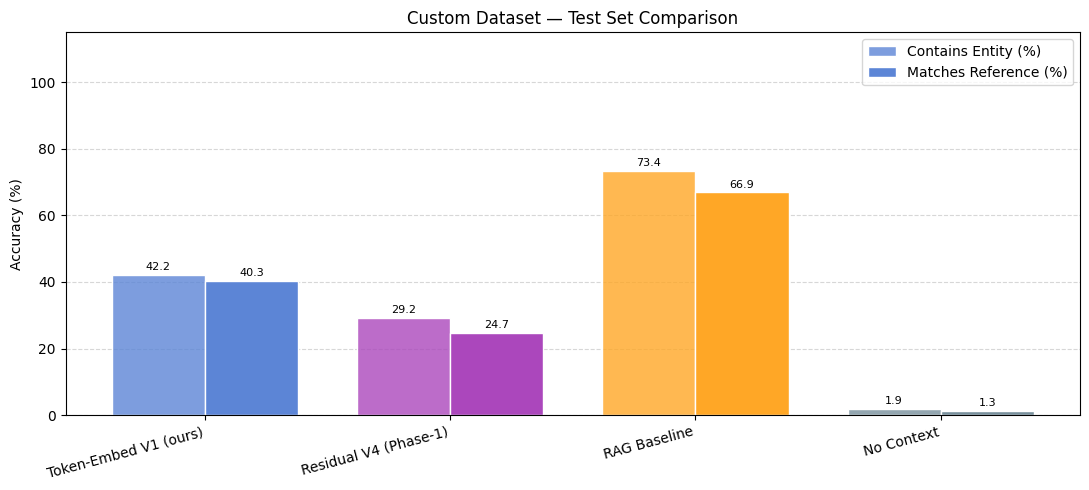

Saved plot.


In [18]:
labels  = list(results.keys())
ce_vals = [v[0] if v[0] is not None else 0 for v in results.values()]
mr_vals = [v[1] if v[1] is not None else 0 for v in results.values()]
colors  = ["#5C85D6", "#AB47BC", "#FFA726", "#78909C"]

x = np.arange(len(labels))
w = 0.38
fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - w/2, ce_vals, w, label="Contains Entity (%)", color=[c + "cc" for c in colors], edgecolor="white")
bars2 = ax.bar(x + w/2, mr_vals, w, label="Matches Reference (%)", color=colors, edgecolor="white")

for bar in list(bars1) + list(bars2):
    if bar.get_height() > 1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
                f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15, ha="right")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Custom Dataset — Test Set Comparison")
ax.set_ylim(0, 115)
ax.yaxis.grid(True, linestyle="--", alpha=0.5)
ax.set_axisbelow(True)
ax.legend()

plots_dir = os.path.join(RESULTS_DIR, "plots")
os.makedirs(plots_dir, exist_ok=True)
plt.tight_layout()
plt.savefig(os.path.join(plots_dir, "comparison_token_embed_v1.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved plot.")